# Comparing Inference Algorithms

This script follows the steps outlined in `src/inference.py` and specifically runs inference for each query with multiple inference algorithms (exact and approximate). We compare convergence rates and error rates of each of the algorithms. 

In [1]:
# Import libraries
import argparse
import logging
import math
import os
import pickle
import time
import re
import warnings

import pyAgrum as gm
import pyAgrum.lib.dynamicBN as gdynbn
import pyAgrum.lib.notebook as gnb
import yaml
warnings.filterwarnings("ignore", category=DeprecationWarning)
import matplotlib.pyplot as plt

# Set logger
logger = logging.getLogger('inference_dbn_logger')

In [2]:
from scipy.spatial import distance
import numpy as np
import pandas as pd 

In [3]:
# Helper function to convert float parameters to strings
def param_val_to_str(param_val):
    """Function used to read the float parameter values and convert them to strings.
    
    For example, if the parameter value is 1.0, it is converted to "1".
    Otherwise, the parameter value 0.2 is converted to _0_2.
    """
    if param_val == 1.0:
        param_val = "1"
    else:
        param_val = str(param_val).replace(".", "_")
        param_val = f"_{param_val}"
    return param_val

In [4]:
def run_inference(dbn, query, delta):
    """Function to run inference on the DBN.

    This function runs inference on the DBN to predict the state of the system at a
    future time step for any query that is specified.

    Args:
        dbn (str): The constructed DBN.
        query (str): Query to run inference on the DBN.
        delta (float): Time interval between time slices.
    Returns: 
        posterior (object): The posterior distribution of the query.
    """
    # Unroll the DBN up till the query slice
    query_slice = math.floor(query['query_time'] / delta)
    dbn_unrolled = gdynbn.unroll2TBN(dbn, query_slice + 1)

    # Set the starting parameters
    for key, val in query['start_parameters'].items():
        if key == 'Lqa':
            dbn_unrolled.cpt('Lqa0')[:] = 0.0
            dbn_unrolled.cpt('Lqa0')[{'Lqa0': str(val)}] = 1.0
            # This part is redundant; it sets the value of Lqai0
            # Inference algorithm should take care of it.
            """
            if 'Lqai0' in dbn_unrolled.names():
                if str(val) == '0':
                    logger.debug(f"Setting Lqai0 to {val}")
                    dbn_unrolled.cpt('Lqai0')[{'Lqai0': 0,
                                               'Lqa0': 0}] = 1.0
                    dbn_unrolled.cpt('Lqai0')[{'Lqai0': 1}] = 0.0
                else:
                    logger.debug(f"Setting Lqai0 to {val}")
                    dbn_unrolled.cpt('Lqai0')[{'Lqai0': 1}] = 0.0
                    dbn_unrolled.cpt('Lqai0')[{'Lqai0': 0}] = 0.0
                    dbn_unrolled.cpt('Lqai0')[{'Lqai0': 1,
                                                'Lqa0': str(val)}] = 1.0
                logger.debug(f"Lqai0: {dbn_unrolled.cpt('Lqai0')}")
                logger.debug(f"Lqai1: {dbn_unrolled.cpt('Lqai1')}")
            logger.debug(f"Lqa0: {dbn_unrolled.cpt('Lqa0')}")
            """
        elif key == 'Lqb':
            dbn_unrolled.cpt('Lqb0')[:] = 0.0
            dbn_unrolled.cpt('Lqb0')[{'Lqb0': str(val)}] = 1.0
            """
            if 'Lqbi0' in dbn_unrolled.names():
                if str(val) == '0':
                    logger.debug(f"Setting Lqbi0 to {val}")
                    dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 0,
                                               'Lqb0': 0}] = 1.0
                    dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 1}] = 0.0
                else:
                    logger.debug(f"Setting Lqbi0 to {val}")
                    dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 1}] = 0.0
                    dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 0}] = 0.0
                    dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 1,
                                                'Lqb0': str(val)}] = 1.0
                logger.debug(f"Lqbi0: {dbn_unrolled.cpt('Lqbi0')}")
                logger.debug(f"Lqbi1: {dbn_unrolled.cpt('Lqbi1')}")
            logger.debug(f"Lqb0: {dbn_unrolled.cpt('Lqb0')}")
            """
        elif key == 'Lqc':
            dbn_unrolled.cpt('Lqc0')[:] = 0.0
            dbn_unrolled.cpt('Lqc0')[{'Lqc0': str(val)}] = 1.0
            """
            if 'Lqci0' in dbn_unrolled.names():
                if str(val) == '0':
                    logger.debug(f"Setting Lqci0 to {val}")
                    dbn_unrolled.cpt('Lqci0')[{'Lqci0': 0,
                                               'Lqc0': 0}] = 1.0
                    dbn_unrolled.cpt('Lqci0')[{'Lqci0': 1}] = 0.0
                else:
                    logger.debug(f"Setting Lqci0 to {val}")
                    dbn_unrolled.cpt('Lqci0')[{'Lqci0': 1}] = 0.0
                    dbn_unrolled.cpt('Lqci0')[{'Lqci0': 0}] = 0.0
                    dbn_unrolled.cpt('Lqci0')[{'Lqci0': 1,
                                                'Lqc0': str(val)}] = 1.0
                logger.debug(f"Lqci0: {dbn_unrolled.cpt('Lqci0')}")
                logger.debug(f"Lqci1: {dbn_unrolled.cpt('Lqci1')}")
            logger.debug(f"Lqc0: {dbn_unrolled.cpt('Lqc0')}")
            """
        elif key in [
                'Lambdaqa', 'Muqa', 'Lambdaqb', 'Muqb', 
                'Lambdaqc', 'Muqc', 'Rab', 'Rbc', 'Rca'
        ]:
            val = param_val_to_str(val)
            for slice_num in range(query_slice + 1):
                dbn_unrolled.cpt(f"{key}{slice_num}")[:] = 0.0
                dbn_unrolled.cpt(f"{key}{slice_num}")[{
                    f"{key}{slice_num}": str(val)
                }] = 1.0

    # Get the maximum queue length vals
    mql = dbn_unrolled.variable('Lqa0').domainSize() - 1

    # Store the conditional variables and values for inference
    conditional_vars = []
    conditional_vals = []

    # Interventions
    if query['interventions']:
        for iv in query['interventions']:
            if iv['intervention_type'] == 'parameter_intervention':
                intervention_val = param_val_to_str(iv['intervention_value'])
                # Step 1. Convert the intervention times to the corresponding slices
                param_intervention_slice = math.floor(iv['intervention_start'] /
                                                      delta)
                # Step 2. Set the intervention values for all slices after the intervention
                for slice_num in range(param_intervention_slice,
                                       query_slice + 1):
                    dbn_unrolled.cpt(
                        f'{iv["intervention_variable"]}{slice_num}')[:] = 0.0
                    dbn_unrolled.cpt(
                        f'{iv["intervention_variable"]}{slice_num}')[{
                            f'{iv["intervention_variable"]}{slice_num}':
                                str(intervention_val)
                        }] = 1.0
            elif iv['intervention_type'] == 'interventional':
                ev_var = f"{iv['intervention_variable']}{math.floor(iv['intervention_start']/delta)}"  # pylint: disable=line-too-long
                ev_val = str(iv['intervention_value'])
                # Step 1. Erase the arcs from the parents of the intervention var
                for parent in dbn_unrolled.parents(ev_var):
                    parent_var = dbn_unrolled.variable(parent).name()
                    dbn_unrolled.eraseArc(parent_var, ev_var)

                # Step 2. Set the evidence to the corresponding value
                dbn_unrolled.cpt(ev_var)[:] = 0.0
                dbn_unrolled.cpt(ev_var)[int(ev_val)] = 1.0
            elif iv['intervention_type'] == 'conditional':
                cond_var = f"{iv['intervention_variable']}{math.floor(iv['intervention_start']/delta)}"  # pylint: disable=line-too-long
                if iv['intervention_variable'] in ['Lqa', 'Lqb', 'Lqc']:
                    cond_val = int(iv['intervention_value'])
                else:
                    cond_val = str(iv['intervention_value'])
                conditional_vars.append(cond_var)
                conditional_vals.append(cond_val)
            elif iv['intervention_type'] == 'additive' or iv[
                    'intervention_type'] == 'subtractive':
                ev_var = f"{iv['intervention_variable']}{math.floor(iv['intervention_start']/delta)}"  # pylint: disable=line-too-long
                ev_val = int(iv['intervention_value'])
                if iv['intervention_type'] == 'additive':
                    shifted_dbn = gm.BayesNet(dbn_unrolled)
                    for ql in range(0, ev_val):
                        shifted_dbn.cpt(ev_var)[{ev_var: ql}] = 0.0
                    for ql in range(ev_val, mql + 1):
                        shifted_dbn.cpt(ev_var)[{
                            ev_var: ql
                        }] = dbn_unrolled.cpt(ev_var)[{
                            ev_var: ql - ev_val
                        }]
                    # Add the remaining probabilities to the last column
                    remainder = 0.0
                    for rem in range(mql - ev_val + 1, mql + 1):
                        remainder += dbn_unrolled.cpt(ev_var)[{ev_var: rem}]
                    shifted_dbn.cpt(ev_var)[{ev_var: mql}] += remainder
                    dbn_unrolled = gm.BayesNet(shifted_dbn)
                elif iv['intervention_type'] == 'subtractive':
                    shifted_dbn = gm.BayesNet(dbn_unrolled)
                    for ql in range(mql - ev_val + 1, mql + 1):
                        shifted_dbn.cpt(ev_var)[{ev_var: ql}] = 0.0
                    for ql in range(0, mql - ev_val + 1):
                        shifted_dbn.cpt(ev_var)[{
                            ev_var: ql
                        }] = dbn_unrolled.cpt(ev_var)[{
                            ev_var: ql + ev_val
                        }]
                    # Add the remaining probabilities to the first column
                    remainder = 0.0
                    for rem in range(0, ev_val):
                        remainder += dbn_unrolled.cpt(ev_var)[{ev_var: rem}]
                    shifted_dbn.cpt(ev_var)[{ev_var: 0}] += remainder
                    dbn_unrolled = gm.BayesNet(shifted_dbn)
    # Inference

    # We want to compare the different inference algorithms (with specific hyperparameters)
    
    # Gibbs Sampling
    gibbs_ie = gm.GibbsSampling(dbn_unrolled)
    gibbs_ie.setBurnIn(1000)
    gibbs_ie.setEpsilon(1e-5)
    
    # Monte Carlo Sampling
    mc_ie = gm.MonteCarloSampling(dbn_unrolled)
    mc_ie.setEpsilon(1e-5)
    
    # Importance Sampling
    is_ie = gm.ImportanceSampling(dbn_unrolled)
    is_ie.setEpsilon(1e-5)

    # Exact Inference
    exact_ie = gm.LazyPropagation(dbn_unrolled)
        
    # Outputs for each of the inference algorithms
    posterior_dists = {
        'gibbs': {},
        'mc': {},
        'is': {},
        'exact': {}
    }    
    inference_times = {
        'gibbs': 0,
        'mc': 0,
        'is': 0,
        'exact': 0
    }
    full_inference_times = {
        'gibbs': 0,
        'mc': 0,
        'is': 0,
        'exact': 0
    }
    
    # Run inference using each of the inference algorithms
    inference_engines = {'gibbs': gibbs_ie, 
                         'mc': mc_ie, 
                         'is': is_ie, 
                         'exact': exact_ie}
    for ie_name, ie in inference_engines.items():
        logger.info(f"Running inference using {ie_name} ...")
        # Start time required to run the inference
        heavy_computation_start_time = time.time()
        ie.makeInference()

        # For all interventions of type 'conditional', set the evidence
        for ev_var, ev_val in zip(conditional_vars, conditional_vals):
            ie.addEvidence(ev_var, ev_val)

        # Extract the posterior probability distribution and return the results
        compute_posterior_start_time = time.time()
        posterior = ie.posterior(
            dbn_unrolled.idFromName(f"{query['query_variable']}{query_slice}"))
        compute_posterior_end_time = time.time()
        posterior_dist = {}
        for i in posterior.loopIn():
            key = str(i)
            key = re.search(r"\:(.*?)\>", key)
            posterior_dist[int(key.group(1))] = float(posterior.get(i))
        
        full_inference_time = compute_posterior_end_time - heavy_computation_start_time
        inference_time = compute_posterior_end_time - compute_posterior_start_time

        # Store the results
        posterior_dists[ie_name][query_slice] = posterior_dist
        inference_times[ie_name] += inference_time
        full_inference_times[ie_name] += full_inference_time

    # Print out the comparison results
    print(f"Inference results for {query['query_variable']} at time slice {query_slice}:")
    for ie_name, ie in inference_engines.items():
        print(f"{ie_name}:")
        print(f"  Posterior distribution: {posterior_dists[ie_name][query_slice]}")
        print(f"  Inference time: {inference_times[ie_name]} seconds")
        print(f"  Full inference time: {full_inference_times[ie_name]} seconds")
        
    # Let us use the notebook to visualize the comparison between each of the inference algorithms and exact inference 
    compareInference(exact_ie, gibbs_ie)
    compareInference(exact_ie, mc_ie)
    compareInference(exact_ie, is_ie)


In [5]:
# Main function to specify a query of interest 
# Specify the parameters for the experiment
CONFIG_FILE = '../configs/indicator-False_inference-exact-lazyprop_nreps-30_pooled-True.json'
EXPERIMENT_NUMBER = 77
SIM_CONFIG = '../configs/simulator.yaml'
TIME_DISC_CONFIG = '../configs/time_discretization.yaml'
DBN_NAME = 'dbn_indicator-False_nreps-30_pooled-True_extrapolation-True'

In [6]:
# Read the configuration file and extract the parameters
with open(CONFIG_FILE, 'r', encoding='utf-8') as file:
    all_configs = yaml.safe_load(file)
config = all_configs[f'experiment_{EXPERIMENT_NUMBER}']

# Extract the parameters
time_discretization_experiment = config['time_discretization_experiment']
constructed_dbn_folder = config['dbn_output_folder']
maximum_queue_length = config['maximum_ql']
dbn_edges = config['dbn_edges']
expt_name = config['expt_name']

# Extract the simulation input parameters
with open(TIME_DISC_CONFIG, 'r',
            encoding='utf-8') as time_discretization_file:
    time_discretization_config = yaml.safe_load(time_discretization_file)
    time_discretization_params = time_discretization_config[
        f'experiment_{time_discretization_experiment}']

with open(SIM_CONFIG, 'r', encoding='utf-8') as sim_file:
    sim_config = yaml.safe_load(sim_file)
    sim_params = sim_config[
        f"experiment_{time_discretization_params['time_series_experiment']}"]
    
sampling_interval = time_discretization_params['sampling_interval']

In [7]:
time_discretization_params

{'time_series_experiment': 12,
 'time_discretization_folder': 'data/discrete_time',
 'sampling_interval': 0.2}

In [8]:
CONSTRUCTED_DBN_FILENAME = f"../{constructed_dbn_folder}/{DBN_NAME}.bif"
logger.info(f"Constructed DBN filename: {CONSTRUCTED_DBN_FILENAME}")

# Load the DBN specified by the BIF file
logger.info("Loading the BN specified by the BIF file ...")
constructed_dbn = gm.BayesNet()
constructed_dbn.loadBIF(CONSTRUCTED_DBN_FILENAME)

logger.info(f"Running inference for experiment {EXPERIMENT_NUMBER}")

### Do the Inference and compare the different algorithms

In [9]:
query = config
delta = sampling_interval
dbn = constructed_dbn


# Unroll the DBN up till the query slice
query_slice = math.floor(query['query_time'] / delta)
dbn_unrolled = gdynbn.unroll2TBN(dbn, query_slice + 1)

# Set the starting parameters
for key, val in query['start_parameters'].items():
    if key == 'Lqa':
        dbn_unrolled.cpt('Lqa0')[:] = 0.0
        dbn_unrolled.cpt('Lqa0')[{'Lqa0': str(val)}] = 1.0
        # This part is redundant; it sets the value of Lqai0
        # Inference algorithm should take care of it.
        """
        if 'Lqai0' in dbn_unrolled.names():
            if str(val) == '0':
                logger.debug(f"Setting Lqai0 to {val}")
                dbn_unrolled.cpt('Lqai0')[{'Lqai0': 0,
                                            'Lqa0': 0}] = 1.0
                dbn_unrolled.cpt('Lqai0')[{'Lqai0': 1}] = 0.0
            else:
                logger.debug(f"Setting Lqai0 to {val}")
                dbn_unrolled.cpt('Lqai0')[{'Lqai0': 1}] = 0.0
                dbn_unrolled.cpt('Lqai0')[{'Lqai0': 0}] = 0.0
                dbn_unrolled.cpt('Lqai0')[{'Lqai0': 1,
                                            'Lqa0': str(val)}] = 1.0
            logger.debug(f"Lqai0: {dbn_unrolled.cpt('Lqai0')}")
            logger.debug(f"Lqai1: {dbn_unrolled.cpt('Lqai1')}")
        logger.debug(f"Lqa0: {dbn_unrolled.cpt('Lqa0')}")
        """
    elif key == 'Lqb':
        dbn_unrolled.cpt('Lqb0')[:] = 0.0
        dbn_unrolled.cpt('Lqb0')[{'Lqb0': str(val)}] = 1.0
        """
        if 'Lqbi0' in dbn_unrolled.names():
            if str(val) == '0':
                logger.debug(f"Setting Lqbi0 to {val}")
                dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 0,
                                            'Lqb0': 0}] = 1.0
                dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 1}] = 0.0
            else:
                logger.debug(f"Setting Lqbi0 to {val}")
                dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 1}] = 0.0
                dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 0}] = 0.0
                dbn_unrolled.cpt('Lqbi0')[{'Lqbi0': 1,
                                            'Lqb0': str(val)}] = 1.0
            logger.debug(f"Lqbi0: {dbn_unrolled.cpt('Lqbi0')}")
            logger.debug(f"Lqbi1: {dbn_unrolled.cpt('Lqbi1')}")
        logger.debug(f"Lqb0: {dbn_unrolled.cpt('Lqb0')}")
        """
    elif key == 'Lqc':
        dbn_unrolled.cpt('Lqc0')[:] = 0.0
        dbn_unrolled.cpt('Lqc0')[{'Lqc0': str(val)}] = 1.0
        """
        if 'Lqci0' in dbn_unrolled.names():
            if str(val) == '0':
                logger.debug(f"Setting Lqci0 to {val}")
                dbn_unrolled.cpt('Lqci0')[{'Lqci0': 0,
                                            'Lqc0': 0}] = 1.0
                dbn_unrolled.cpt('Lqci0')[{'Lqci0': 1}] = 0.0
            else:
                logger.debug(f"Setting Lqci0 to {val}")
                dbn_unrolled.cpt('Lqci0')[{'Lqci0': 1}] = 0.0
                dbn_unrolled.cpt('Lqci0')[{'Lqci0': 0}] = 0.0
                dbn_unrolled.cpt('Lqci0')[{'Lqci0': 1,
                                            'Lqc0': str(val)}] = 1.0
            logger.debug(f"Lqci0: {dbn_unrolled.cpt('Lqci0')}")
            logger.debug(f"Lqci1: {dbn_unrolled.cpt('Lqci1')}")
        logger.debug(f"Lqc0: {dbn_unrolled.cpt('Lqc0')}")
        """
    elif key in [
            'Lambdaqa', 'Muqa', 'Lambdaqb', 'Muqb', 
            'Lambdaqc', 'Muqc', 'Rab', 'Rbc', 'Rca'
    ]:
        val = param_val_to_str(val)
        for slice_num in range(query_slice + 1):
            dbn_unrolled.cpt(f"{key}{slice_num}")[:] = 0.0
            dbn_unrolled.cpt(f"{key}{slice_num}")[{
                f"{key}{slice_num}": str(val)
            }] = 1.0

# Get the maximum queue length vals
mql = dbn_unrolled.variable('Lqa0').domainSize() - 1

# Store the conditional variables and values for inference
conditional_vars = []
conditional_vals = []

# Interventions
if query['interventions']:
    for iv in query['interventions']:
        if iv['intervention_type'] == 'parameter_intervention':
            intervention_val = param_val_to_str(iv['intervention_value'])
            # Step 1. Convert the intervention times to the corresponding slices
            param_intervention_slice = math.floor(iv['intervention_start'] /
                                                    delta)
            # Step 2. Set the intervention values for all slices after the intervention
            for slice_num in range(param_intervention_slice,
                                    query_slice + 1):
                dbn_unrolled.cpt(
                    f'{iv["intervention_variable"]}{slice_num}')[:] = 0.0
                dbn_unrolled.cpt(
                    f'{iv["intervention_variable"]}{slice_num}')[{
                        f'{iv["intervention_variable"]}{slice_num}':
                            str(intervention_val)
                    }] = 1.0
        elif iv['intervention_type'] == 'interventional':
            ev_var = f"{iv['intervention_variable']}{math.floor(iv['intervention_start']/delta)}"  # pylint: disable=line-too-long
            ev_val = str(iv['intervention_value'])
            # Step 1. Erase the arcs from the parents of the intervention var
            for parent in dbn_unrolled.parents(ev_var):
                parent_var = dbn_unrolled.variable(parent).name()
                dbn_unrolled.eraseArc(parent_var, ev_var)

            # Step 2. Set the evidence to the corresponding value
            dbn_unrolled.cpt(ev_var)[:] = 0.0
            dbn_unrolled.cpt(ev_var)[int(ev_val)] = 1.0
        elif iv['intervention_type'] == 'conditional':
            cond_var = f"{iv['intervention_variable']}{math.floor(iv['intervention_start']/delta)}"  # pylint: disable=line-too-long
            if iv['intervention_variable'] in ['Lqa', 'Lqb', 'Lqc']:
                cond_val = int(iv['intervention_value'])
            else:
                cond_val = str(iv['intervention_value'])
            conditional_vars.append(cond_var)
            conditional_vals.append(cond_val)
        elif iv['intervention_type'] == 'additive' or iv[
                'intervention_type'] == 'subtractive':
            ev_var = f"{iv['intervention_variable']}{math.floor(iv['intervention_start']/delta)}"  # pylint: disable=line-too-long
            ev_val = int(iv['intervention_value'])
            if iv['intervention_type'] == 'additive':
                shifted_dbn = gm.BayesNet(dbn_unrolled)
                for ql in range(0, ev_val):
                    shifted_dbn.cpt(ev_var)[{ev_var: ql}] = 0.0
                for ql in range(ev_val, mql + 1):
                    shifted_dbn.cpt(ev_var)[{
                        ev_var: ql
                    }] = dbn_unrolled.cpt(ev_var)[{
                        ev_var: ql - ev_val
                    }]
                # Add the remaining probabilities to the last column
                remainder = 0.0
                for rem in range(mql - ev_val + 1, mql + 1):
                    remainder += dbn_unrolled.cpt(ev_var)[{ev_var: rem}]
                shifted_dbn.cpt(ev_var)[{ev_var: mql}] += remainder
                dbn_unrolled = gm.BayesNet(shifted_dbn)
            elif iv['intervention_type'] == 'subtractive':
                shifted_dbn = gm.BayesNet(dbn_unrolled)
                for ql in range(mql - ev_val + 1, mql + 1):
                    shifted_dbn.cpt(ev_var)[{ev_var: ql}] = 0.0
                for ql in range(0, mql - ev_val + 1):
                    shifted_dbn.cpt(ev_var)[{
                        ev_var: ql
                    }] = dbn_unrolled.cpt(ev_var)[{
                        ev_var: ql + ev_val
                    }]
                # Add the remaining probabilities to the first column
                remainder = 0.0
                for rem in range(0, ev_val):
                    remainder += dbn_unrolled.cpt(ev_var)[{ev_var: rem}]
                shifted_dbn.cpt(ev_var)[{ev_var: 0}] += remainder
                dbn_unrolled = gm.BayesNet(shifted_dbn)
# Inference
    
# Outputs for each of the inference algorithms
posterior_dists = {
    'gibbs': {},
    'mc': {},
    'is': {},
    'exact': {}
}    
inference_times = {
    'gibbs': 0,
    'mc': 0,
    'is': 0,
    'exact': 0
}
full_inference_times = {
    'gibbs': 0,
    'mc': 0,
    'is': 0,
    'exact': 0
}

In [10]:
# Run the inference and return the results 
def conduct_inference(ie_name, ie):
    logger.info(f"Running inference using {ie_name} ...")
    
    # Start time required to run the inference
    heavy_computation_start_time = time.time()
    if ie_name != 'exact':
        gnb.animApproximationScheme(ie)
    ie.makeInference()

    # For all interventions of type 'conditional', set the evidence
    for ev_var, ev_val in zip(conditional_vars, conditional_vals):
        ie.addEvidence(ev_var, ev_val)

    # Extract the posterior probability distribution and return the results
    compute_posterior_start_time = time.time()
    posterior = ie.posterior(
        dbn_unrolled.idFromName(f"{query['query_variable']}{query_slice}"))
    compute_posterior_end_time = time.time()
    posterior_dist = {}
    for i in posterior.loopIn():
        key = str(i)
        key = re.search(r"\:(.*?)\>", key)
        posterior_dist[int(key.group(1))] = float(posterior.get(i))

    full_inference_time = compute_posterior_end_time - heavy_computation_start_time
    inference_time = compute_posterior_end_time - compute_posterior_start_time

    # Store the results
    posterior_dists[ie_name][query_slice] = posterior_dist
    inference_times[ie_name] += inference_time
    full_inference_times[ie_name] += full_inference_time

    # Print out the comparison results
    print(f"Inference results for {query['query_variable']} at time slice {query_slice}:")
    print(f"{ie_name}:")
    print(f"  Posterior distribution: {posterior_dists[ie_name][query_slice]}")
    print(f"  Inference time: {inference_times[ie_name]} seconds")
    print(f"  Full inference time: {full_inference_times[ie_name]} seconds")
    
    return posterior_dist, inference_time, full_inference_time

In [11]:
exact_ie = gm.LazyPropagation(dbn_unrolled)
exact_posterior_dist, exact_inference_time, exact_full_inference_time = conduct_inference('exact', exact_ie)

Inference results for Lqa at time slice 20:
exact:
  Posterior distribution: {0: 0.41269927838938636, 1: 0.25338357117710214, 2: 0.1738497217347989, 3: 0.10100768493773038, 4: 0.042580905760293254, 5: 0.012947034494792918, 6: 0.002937084869732641, 7: 0.0005144961714300191, 8: 7.152207757896383e-05, 9: 8.025015030799098e-06, 10: 6.55891290969946e-07, 11: 1.945566495573922e-08, 12: 2.516767144454342e-11}
  Inference time: 0.0032880306243896484 seconds
  Full inference time: 40.45201897621155 seconds


In [12]:
def compute_jsd(p, q):
    jsd = distance.jensenshannon(list(p.values()), list(q.values()))
    return jsd
    
def plot_posterior(exact_posterior, approx_posterior):
    fig = plt.Figure(figsize=(4, 4))
    plt.scatter(exact_posterior.keys(), exact_posterior.values(), label='Exact Inference')
    plt.scatter(approx_posterior.keys(), approx_posterior.values(), label='Approximation')
    plt.plot(exact_posterior.keys(), exact_posterior.values())
    plt.plot(approx_posterior.keys(), approx_posterior.values())
    plt.legend()
    plt.xlabel('Queue Length')
    plt.ylabel('Posterior Distribution')
    # Round to 3 decimal places
    jsd = round(compute_jsd(exact_posterior, approx_posterior), 3)
    plt.title('Exact vs. Approximation \n JSD: ' + str(jsd))
    plt.show()

## Gibbs Sampling vs. Exact Inference

Inference results for Lqa at time slice 20:
gibbs:
  Posterior distribution: {0: 0.31266666666666665, 1: 0.3469333333333333, 2: 0.20746666666666666, 3: 0.09666666666666666, 4: 0.03306666666666667, 5: 0.0032, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0, 12: 0.0}
  Inference time: 9.489059448242188e-05 seconds
  Full inference time: 63.717849254608154 seconds


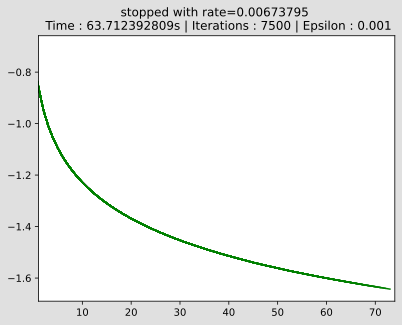

In [13]:
# Gibbs Sampling
gibbs_ie = gm.GibbsSampling(dbn_unrolled)
gibbs_ie.setBurnIn(100)
gibbs_ie.setEpsilon(1e-3)
gibbs_posterior_dist, gibbs_inference_time, gibbs_full_inference_time = conduct_inference('gibbs', gibbs_ie)

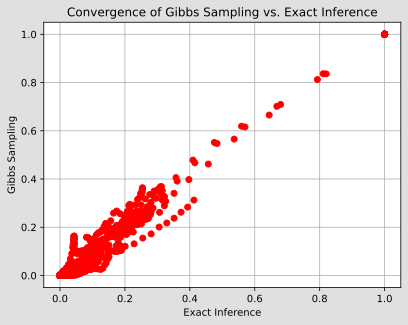

In [14]:
exact = []
appro = []
errmax = 0

for node in dbn_unrolled.nodes():
    exact += exact_ie.posterior(node).tolist()
    appro += gibbs_ie.posterior(node).tolist()
    errmax = max(errmax, (exact_ie.posterior(node) - gibbs_ie.posterior(node)).abs().max())

if errmax < 1e-10:
    errmax = 0
fig = plt.Figure(figsize=(4, 4))
ax = plt.gca()  # default axis for plt    
ax.plot(exact, appro, 'ro')
ax.set_xlabel('Exact Inference')
ax.set_ylabel('Gibbs Sampling')
ax.set_title('Convergence of Gibbs Sampling vs. Exact Inference')
ax.grid(True)
plt.show()


In [15]:
# Compute the Jensen-shannon distance between the exact and gibbs posterior distribution
print('JSD between exact and gibbs: ', compute_jsd(exact_posterior_dist, gibbs_posterior_dist))

JSD between exact and gibbs:  0.10481193765690291


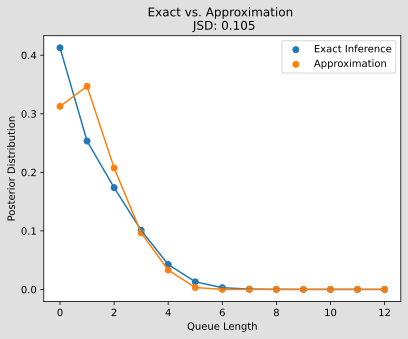

In [16]:
# Plot the two posterior distributions
plot_posterior(exact_posterior_dist, gibbs_posterior_dist)

## Monte Carlo Sampling

Inference results for Lqa at time slice 20:
mc:
  Posterior distribution: {0: 0.414375, 1: 0.25026041666666665, 2: 0.16989583333333333, 3: 0.10104166666666667, 4: 0.042083333333333334, 5: 0.012005208333333333, 6: 0.0027864583333333335, 7: 0.00036458333333333335, 8: 0.00013020833333333333, 9: 2.604166666666667e-05, 10: 5.208333333333334e-05, 11: 0.00013020833333333333, 12: 0.006848958333333334}
  Inference time: 5.507469177246094e-05 seconds
  Full inference time: 292.97413635253906 seconds


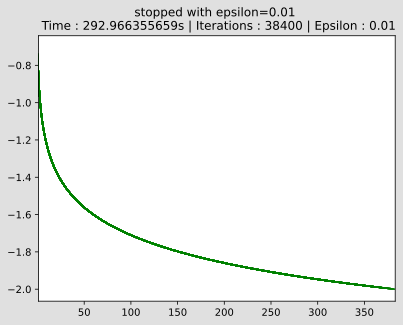

In [17]:
mc_ie = gm.MonteCarloSampling(dbn_unrolled)
mc_ie.setEpsilon(1e-2)
mc_posterior_dist, mc_inference_time, mc_full_inference_time = conduct_inference('mc', mc_ie)

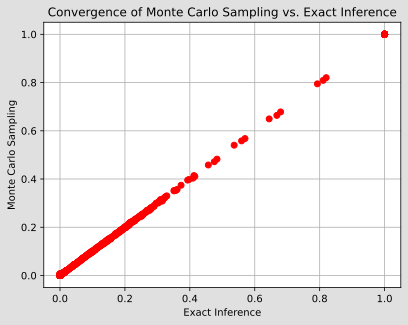

In [18]:
# Compare to exact inference
exact = []
appro = []
errmax = 0

for node in dbn_unrolled.nodes():
    exact += exact_ie.posterior(node).tolist()
    appro += mc_ie.posterior(node).tolist()
    errmax = max(errmax, (exact_ie.posterior(node) - mc_ie.posterior(node)).abs().max())

if errmax < 1e-10:
    errmax = 0
fig = plt.Figure(figsize=(4, 4))
ax = plt.gca()  # default axis for plt
ax.plot(exact, appro, 'ro')
ax.set_xlabel('Exact Inference')
ax.set_ylabel('Monte Carlo Sampling')
ax.set_title('Convergence of Monte Carlo Sampling vs. Exact Inference')
ax.grid(True)
plt.show()

JSD between exact and mc:  0.049760968262267564


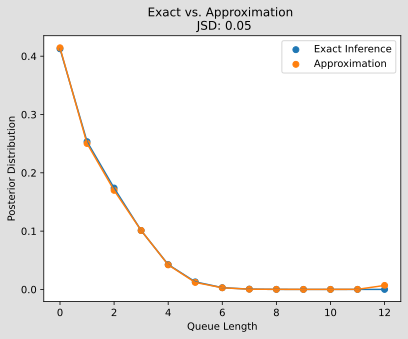

In [19]:
# Compute the Jensen-shannon distance between the exact and mc posterior distribution
print('JSD between exact and mc: ', compute_jsd(exact_posterior_dist, mc_posterior_dist))
# Plot the two posterior distributions
plot_posterior(exact_posterior_dist, mc_posterior_dist)

## Importance Sampling

In [22]:
is_ie = gm.ImportanceSampling(dbn_unrolled)
is_ie.setEpsilon(1e-2)
is_posterior_dist, is_inference_time, is_full_inference_time = conduct_inference('is', is_ie)

FatalError: [pyAgrum] Fatal error: Normalization for a potential that sum to 0 in 
                                                ||  Lqb10                                                                                                                          |
Lambda|Muqb10|Lqb9  |Rab10 |Lambda|Muqa10|Lqa9  ||0        |1        |2        |3        |4        |5        |6        |7        |8        |9        |10       |11       |12       |
------|------|------|------|------|------|------||---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|
_0_1  |_0_9  |0     |_0_2  |_0_1  |_0_9  |0     || 0.9870  | 0.0130  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  |
_0_2  |_0_9  |0     |_0_2  |_0_1  |_0_9  |0     || 0.9642  | 0.0345  | 0.0013  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  |
_0_1  |1    

<Figure size 640x480 with 0 Axes>

In [ ]:
# Compare to exact inference
exact = []
appro = []
errmax = 0

for node in dbn_unrolled.nodes():
    exact += exact_ie.posterior(node).tolist()  
    appro += is_ie.posterior(node).tolist()
    errmax = max(errmax, (exact_ie.posterior(node) - is_ie.posterior(node)).abs().max())

if errmax < 1e-10:
    errmax = 0
fig = plt.Figure(figsize=(4, 4))
ax = plt.gca()  # default axis for plt
ax.plot(exact, appro, 'ro')
ax.set_xlabel('Exact Inference')
ax.set_ylabel('Importance Sampling')
ax.set_title('Convergence of Importance Sampling vs. Exact Inference')
ax.grid(True)
plt.show()


<Figure size 640x480 with 0 Axes>